In [1]:
import os
import datetime
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import colorcet as cc
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import pandas as pd
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import HoverTool, Title
from pathlib import Path
import folium
import rioxarray
import netCDF4

from shapely.geometry import box

from blackmarble.extract import bm_extract
from blackmarble.raster import bm_raster

import xarray as xr
import numpy as np

#Local Functions
import sys
sys.path.append('../src')
from ntl_functions import plot_NASA_NTL, filter_dataset_by_bounding_box, mask_dataset_by_geometry

#Settings
%load_ext autoreload
%autoreload 2

plt.rcParams["figure.figsize"] = (18, 10)
pd.set_option('display.max_rows', 50)

In [2]:
# Define a list of color hex codes or names (from low to high)
color_list = ["#6666cc", "#aa66cc", "#ee99ee", "#ffb366", "#ffff99", 
             #"#FFFFFF"
             ]

# Create a colormap from that list
NTL_cmap = mcolors.LinearSegmentedColormap.from_list("my_colormap", color_list).reversed()

In [3]:
somaliland_shp = gpd.read_file(
    "../data/Combined_Datasets/Somaliland_with_berbera/somaliland_with_berbera.shp"
)
SL_Berbera_VNP46A4_EY_2012_24 = xr.open_dataset("../data/NTL_Data_A4/141225_SL_Berbera_VNP46A4_EY_2012_24.nc")

logged_NTL = xr.where(
    SL_Berbera_VNP46A4_EY_2012_24 > 0, 
    np.log(SL_Berbera_VNP46A4_EY_2012_24), 
    0  # Assign 0 for non-positive values
)

logged_NTL = mask_dataset_by_geometry(logged_NTL, somaliland_shp)

c:\Users\samsa\Documents\NTL_Somaliland\venv\Lib\site-packages\xarray\computation\apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


In [ ]:
#Regions
maroodi_jeex = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp[somaliland_shp["admin1Name"]=="Maroodi Jeex"]), somaliland_shp[somaliland_shp["admin1Name"]== "Maroodi Jeex"])
togdheer = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp[somaliland_shp["admin1Name"]=="Togdheer"]), somaliland_shp[somaliland_shp["admin1Name"]== "Togdheer"])
awdal = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp[somaliland_shp["admin1Name"]=="Awdal"]), somaliland_shp[somaliland_shp["admin1Name"]== "Awdal"])
sool = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp[somaliland_shp["admin1Name"]=="Sool"]), somaliland_shp[somaliland_shp["admin1Name"]== "Sool"])
sanaag = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp[somaliland_shp["admin1Name"]=="Sanaag"]), somaliland_shp[somaliland_shp["admin1Name"]== "Sanaag"])
sahil = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp[somaliland_shp["admin1Name"]=="Sahil"]), somaliland_shp[somaliland_shp["admin1Name"]== "Sahil"])


logged_maroodi_jeex = filter_dataset_by_bounding_box(mask_dataset_by_geometry(logged_NTL, somaliland_shp[somaliland_shp["admin1Name"]=="Maroodi Jeex"]), somaliland_shp[somaliland_shp["admin1Name"]== "Maroodi Jeex"])
logged_togdheer = filter_dataset_by_bounding_box(mask_dataset_by_geometry(logged_NTL, somaliland_shp[somaliland_shp["admin1Name"]=="Togdheer"]), somaliland_shp[somaliland_shp["admin1Name"]== "Togdheer"])
logged_awdal = filter_dataset_by_bounding_box(mask_dataset_by_geometry(logged_NTL, somaliland_shp[somaliland_shp["admin1Name"]=="Awdal"]), somaliland_shp[somaliland_shp["admin1Name"]== "Awdal"])
logged_sool = filter_dataset_by_bounding_box(mask_dataset_by_geometry(logged_NTL, somaliland_shp[somaliland_shp["admin1Name"]=="Sool"]), somaliland_shp[somaliland_shp["admin1Name"]== "Sool"])
logged_sanaag = filter_dataset_by_bounding_box(mask_dataset_by_geometry(logged_NTL, somaliland_shp[somaliland_shp["admin1Name"]=="Sanaag"]), somaliland_shp[somaliland_shp["admin1Name"]== "Sanaag"])
logged_sahil = filter_dataset_by_bounding_box(mask_dataset_by_geometry(logged_NTL, somaliland_shp[somaliland_shp["admin1Name"]=="Sahil"]), somaliland_shp[somaliland_shp["admin1Name"]== "Sahil"])



region_datasets = [
    maroodi_jeex,
    sahil,
    awdal,
    togdheer,
    sanaag,
    sool,
]

log_region_datasets = [
    logged_maroodi_jeex,
    logged_sahil,
    logged_awdal,
    logged_togdheer,
    logged_sanaag,
    logged_sool,
]

region_names = [
    "Maroodi Jeex",
    "Sahil",
    "Awdal",
    "Togdheer",
    "Sanaag",
    "Sool",
]



region_list = dict(zip(region_names, region_datasets))
log_region_list = dict(zip(region_names, log_region_datasets))

all_region_yearly_sums = {}

for region_name, region_data in zip(region_names, region_datasets):
    yearly_sums = []
    for year in range(2012, 2024):
        try:
            value = region_data["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01").sum().item()
        except KeyError:
            value = np.nan  # If the date is missing
        yearly_sums.append(round(value, 1))
    all_region_yearly_sums[region_name] = yearly_sums


regions = pd.DataFrame(all_region_yearly_sums)
regions["Year"] = list(range(2012, 2024))
regions = regions[["Year"] + region_names]

regions["Total"] = regions[region_names].sum(axis=1)

In [5]:
#Cities
HGA = gpd.read_file("../data/Combined_Datasets/Hargeisa_shp/HGA.shp")
Berbera = gpd.read_file("../data/Combined_Datasets/Berbera_shp/Berbera.shp")
Burao = gpd.read_file("../data/Combined_Datasets/Burao_shp/Burao.shp")
Boroma = gpd.read_file("../data/Combined_Datasets/Boroma_shp/Boroma.shp")
Erigavo = gpd.read_file("../data/Combined_Datasets/Erigavo_shp/Erigavo.shp")
Las_Anod = gpd.read_file("../data/Combined_Datasets/Las_Anod_shp/Las_Anod.shp")

# For graphing
HGA_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, HGA)
Berbera_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Berbera)
Burao_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Burao)
Boroma_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Boroma)
Erigavo_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Erigavo)
Las_Anod_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Las_Anod)

cities_datasets = [HGA_NTL,
          Berbera_NTL,
          Boroma_NTL,
          Burao_NTL,
          Erigavo_NTL,
          Las_Anod_NTL
         ]

cities_names = ["Hargeisa",
                "Berbera",
                "Boroma",
                "Burao",
                "Erigavo",
                "Las Anod"
               ]

all_city_yearly_sums = {}

for city_name, city_data in zip(cities_names, cities_datasets):
    yearly_sums = []
    for year in range(2012, 2024):
        try:
            value = city_data["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01").sum().item()
        except KeyError:
            value = np.nan  # If the date is missing
        yearly_sums.append(round(value, 1))
    all_city_yearly_sums[city_name] = yearly_sums


cities = pd.DataFrame(all_city_yearly_sums)
cities["Year"] = list(range(2012, 2024))
cities = cities[["Year"] + cities_names]
cities["Total Cities"] = cities[cities_names].sum(axis=1)

In [6]:
percentage_city_region = pd.DataFrame()

for i in range(0,6):
    region = list(region_list.keys())[i]
    city_name = cities_names[i]
    percentage_city_region[region] = round(cities[city_name]/regions[region], 3)*100

percentage_city_region["Total"] = round(cities["Total Cities"]/regions["Total"], 3)*100

percentage_city_region["Year"] = list(range(2012, 2024))
percentage_city_region = percentage_city_region[["Year"] + list(percentage_city_region.columns)[:-1]]


percentage_region_total = pd.DataFrame()

for i in range(0,6):
    region = list(region_list.keys())[i]
    percentage_region_total[region] = round(regions[region]/regions["Total"], 3)*100

percentage_region_total["Year"] = list(range(2012, 2024))
percentage_region_total = percentage_region_total[["Year"] + list(percentage_region_total.columns)[:-1]]

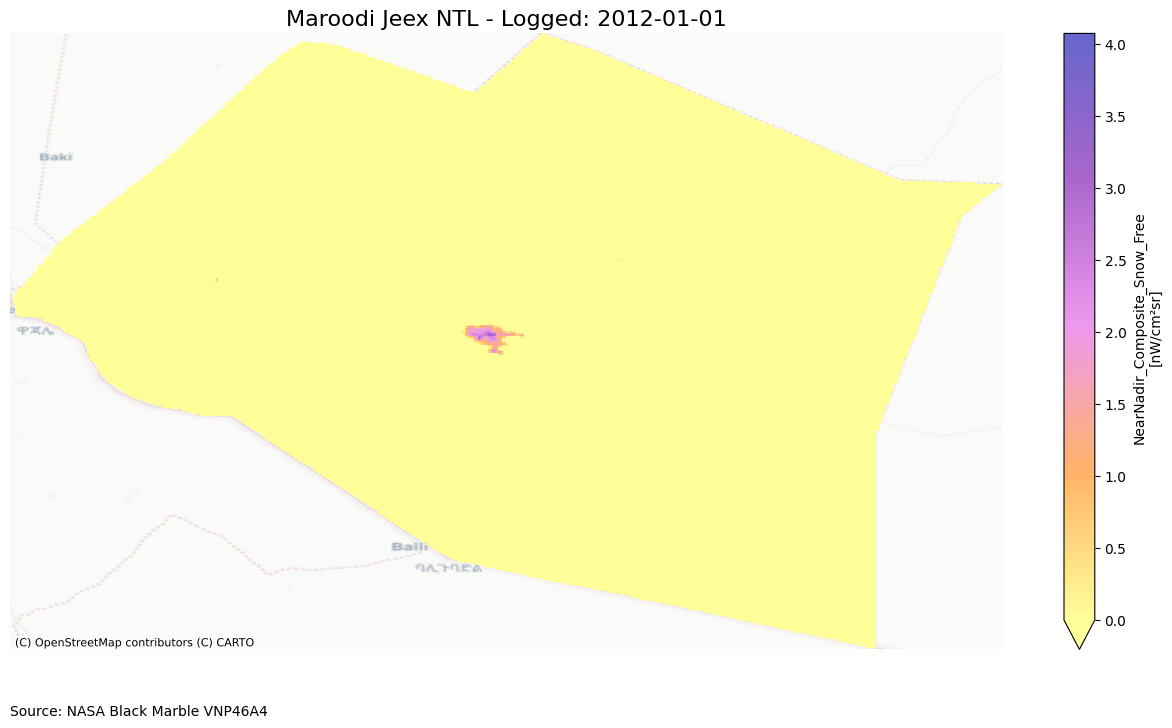

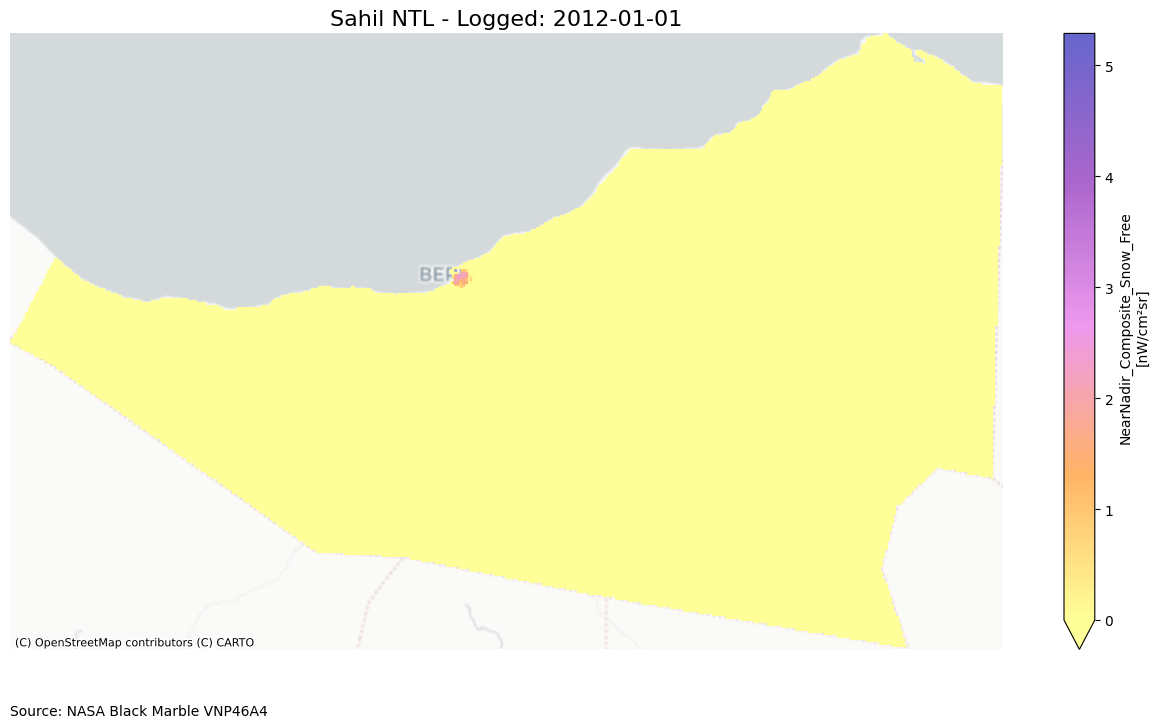

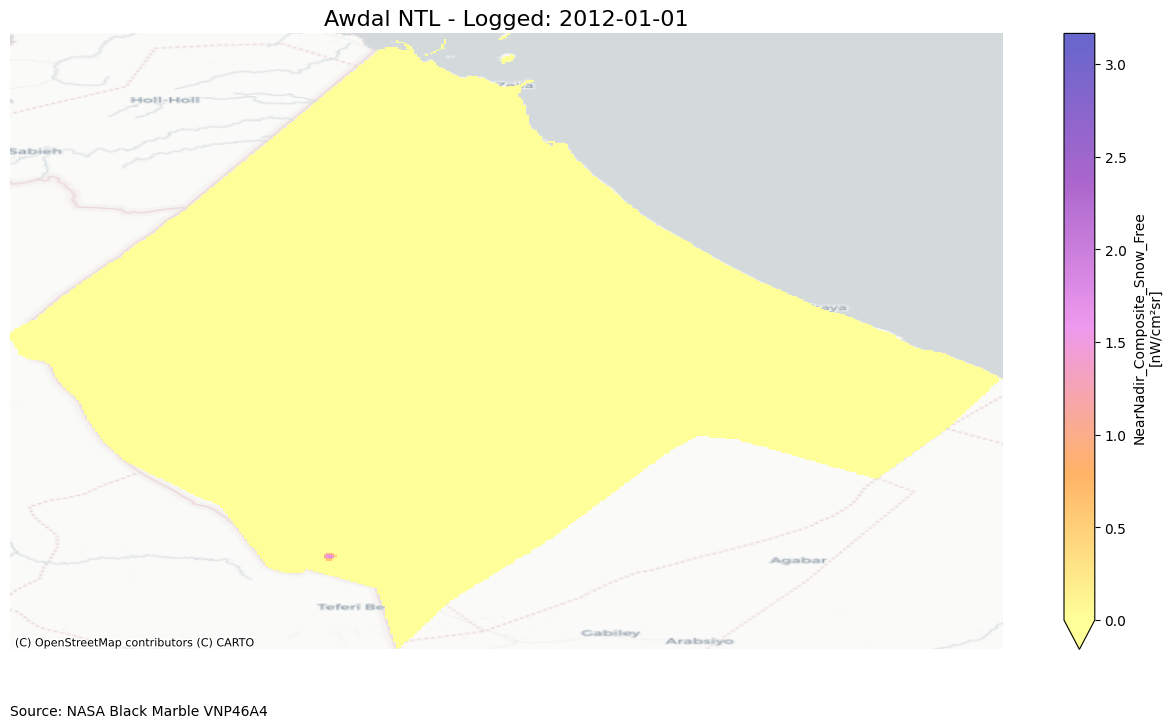

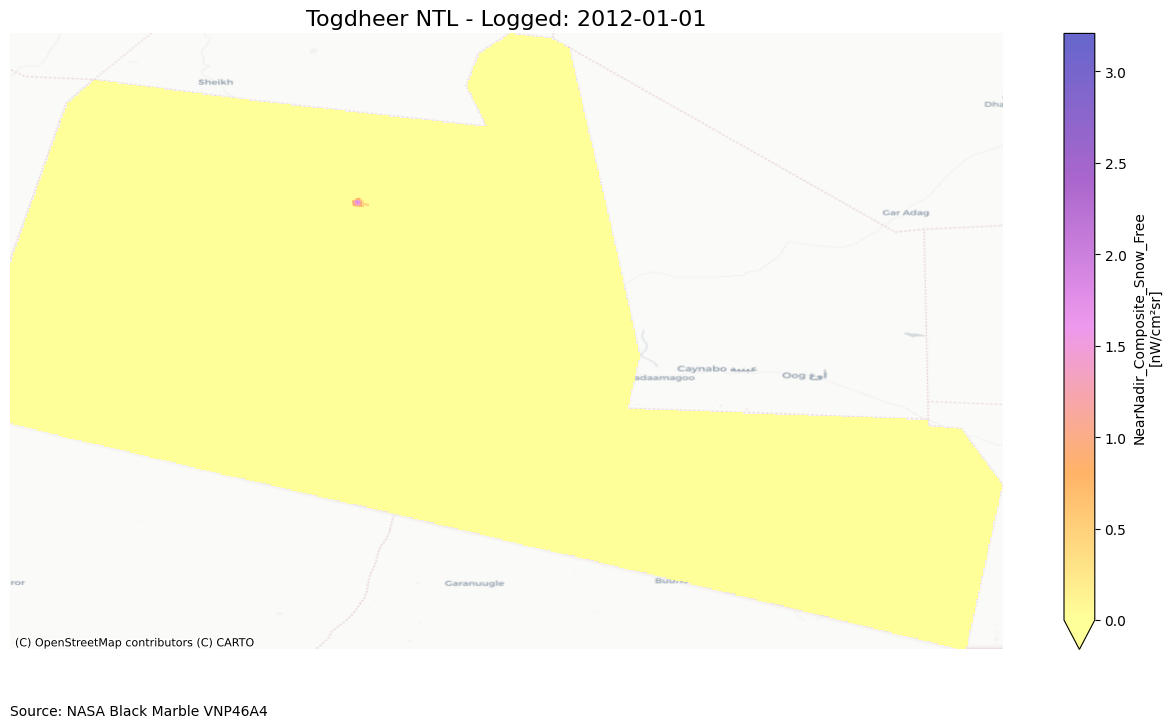

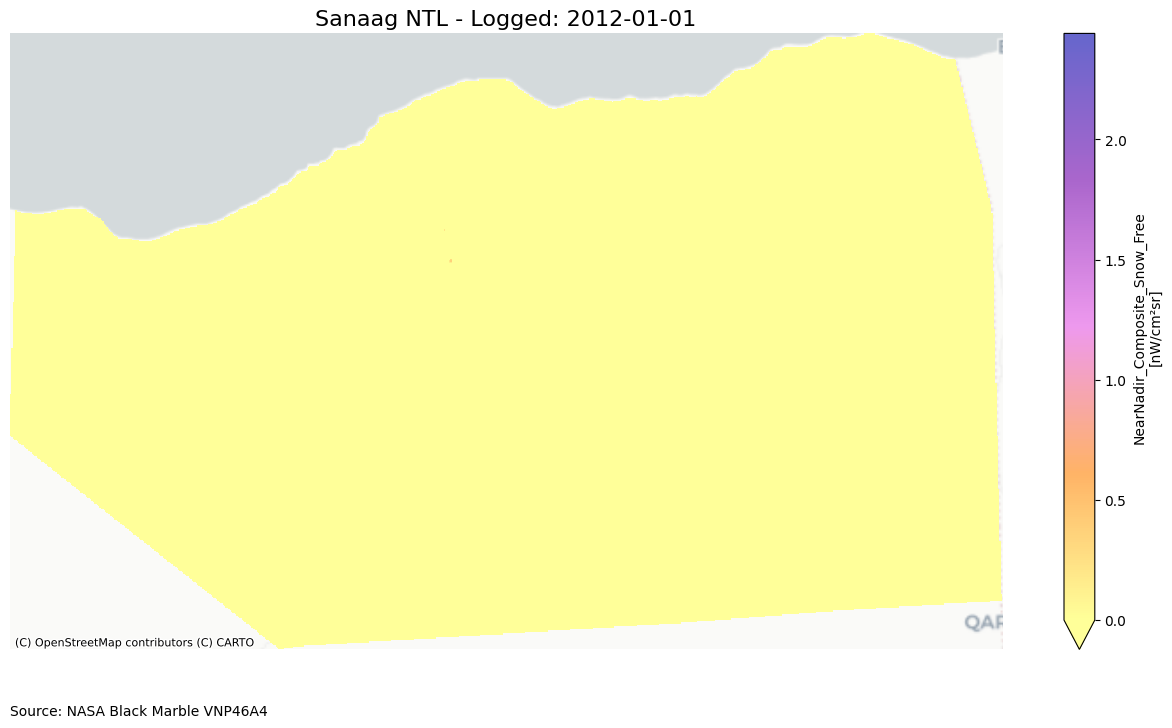

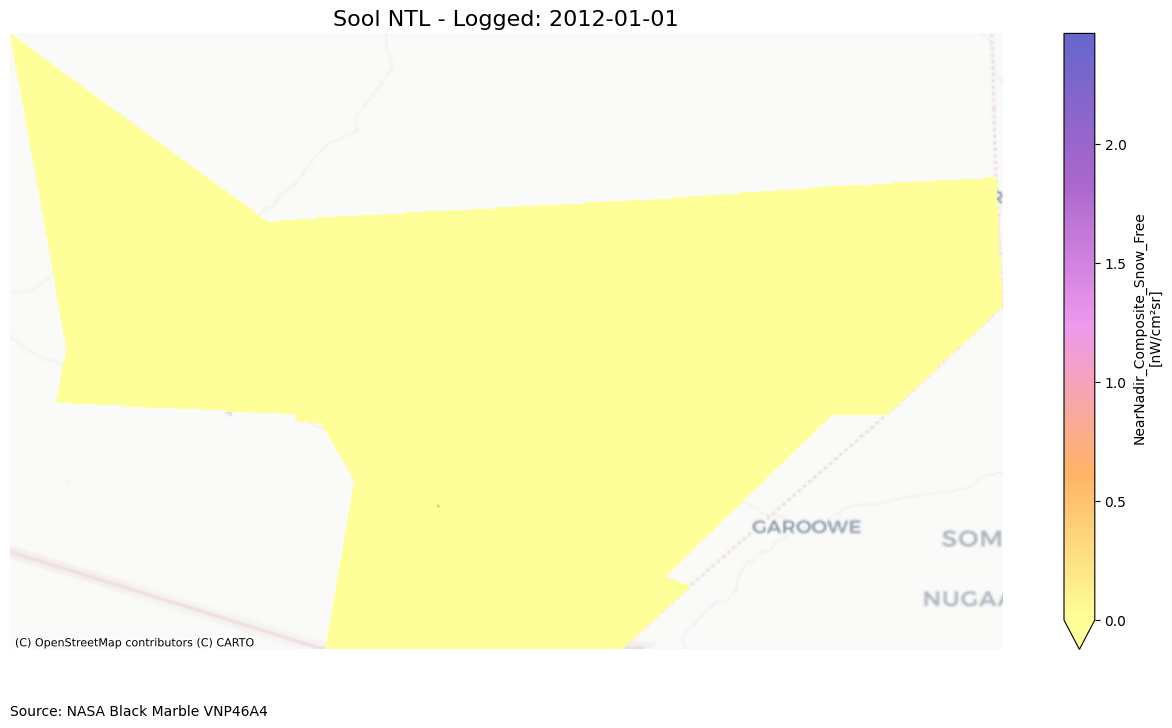

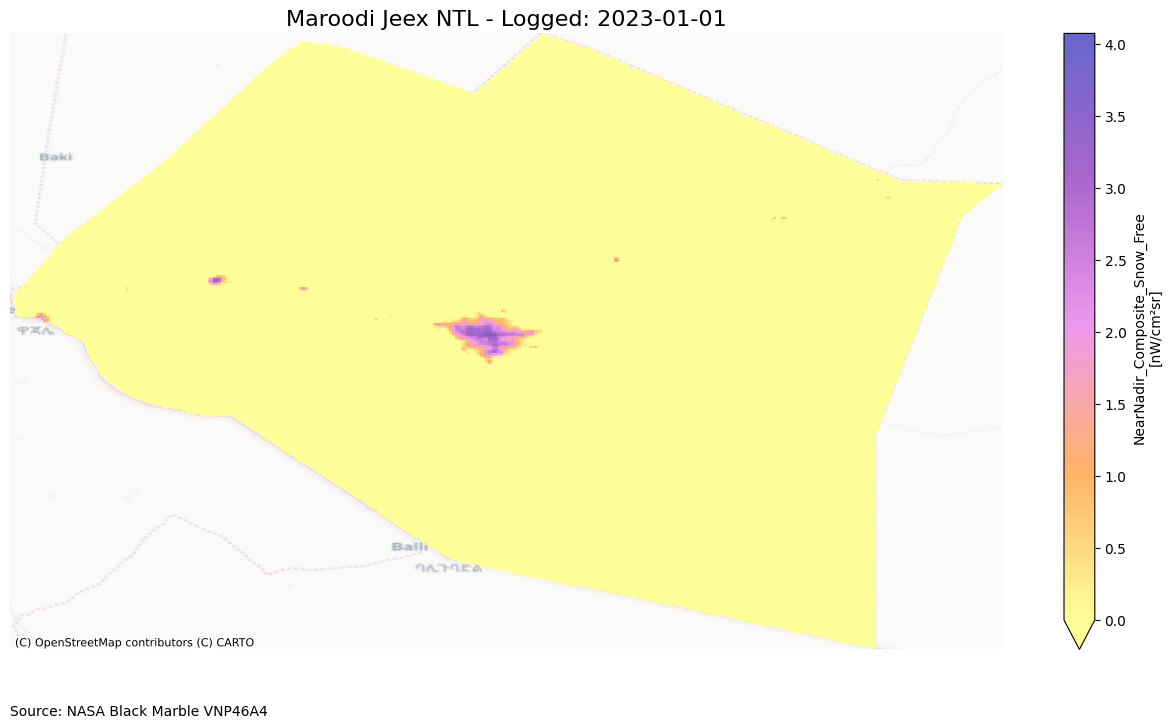

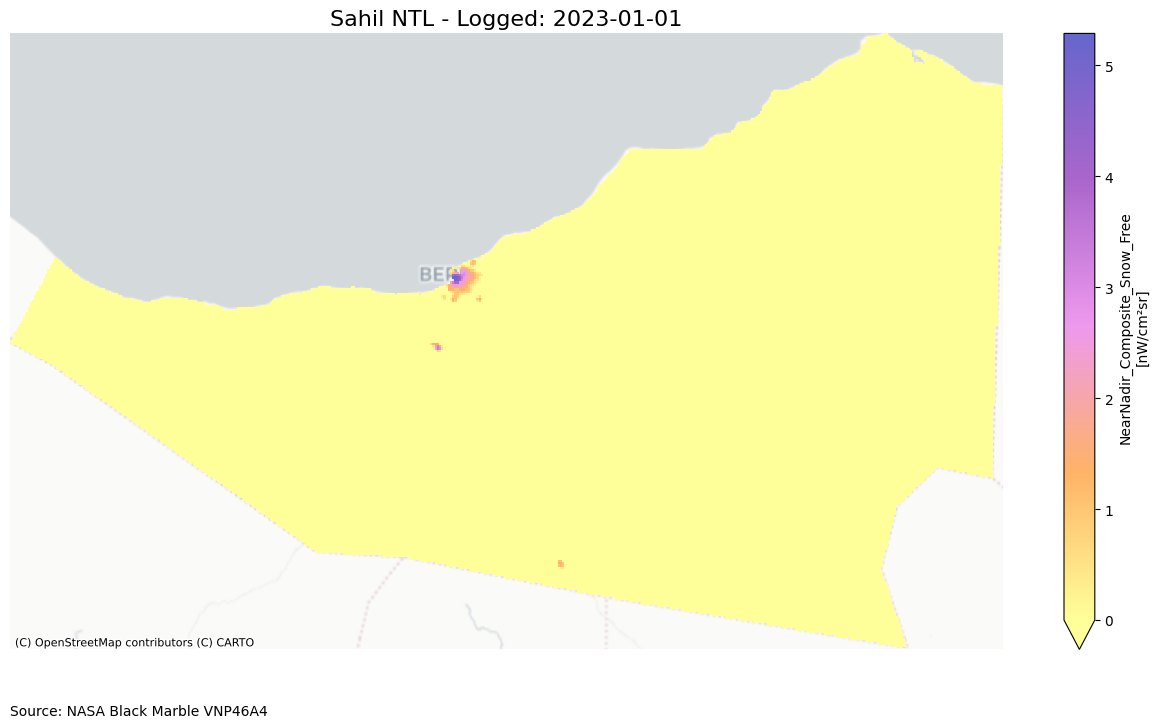

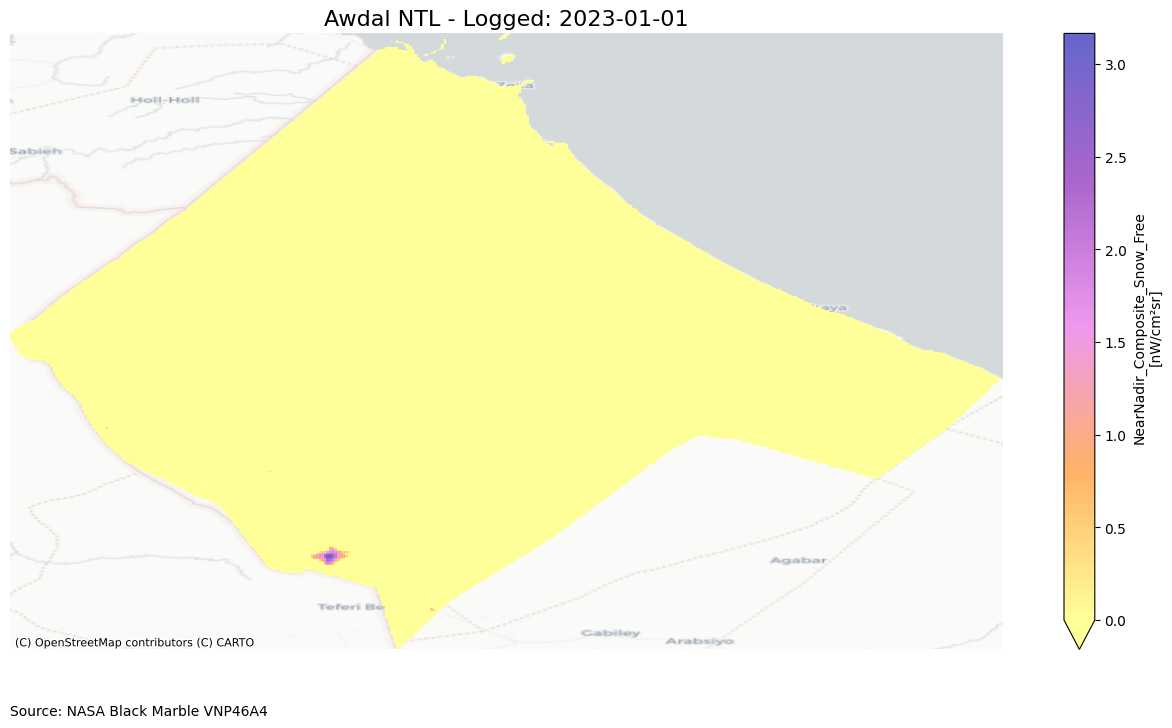

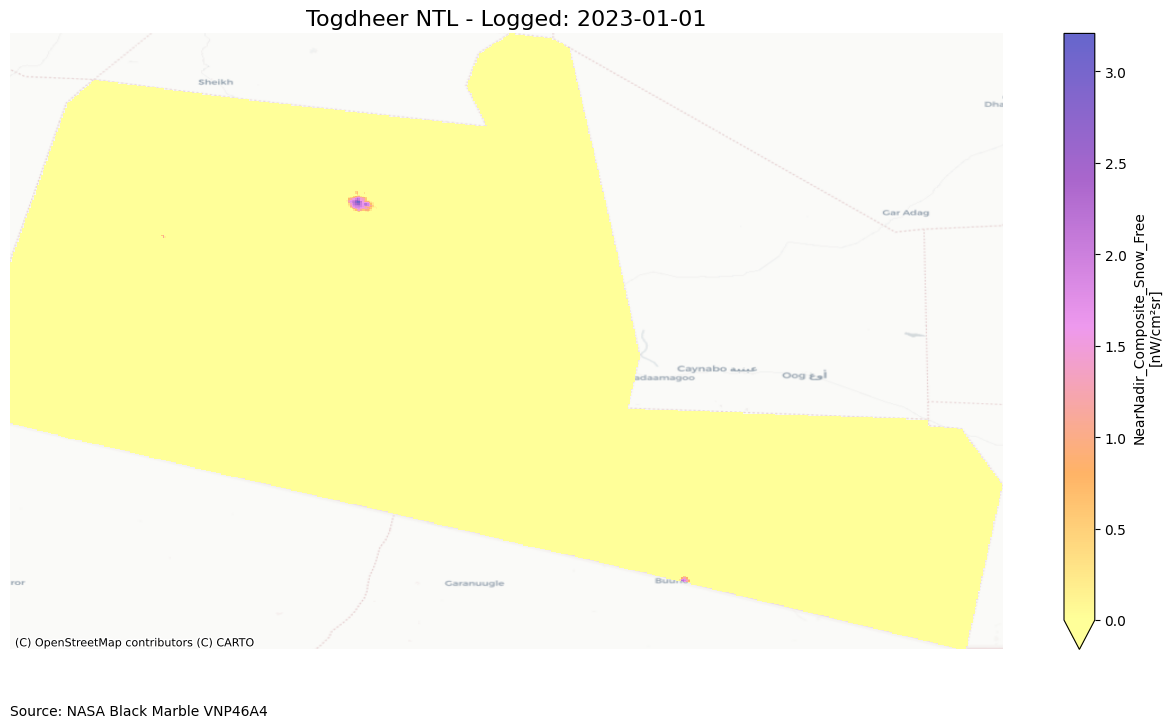

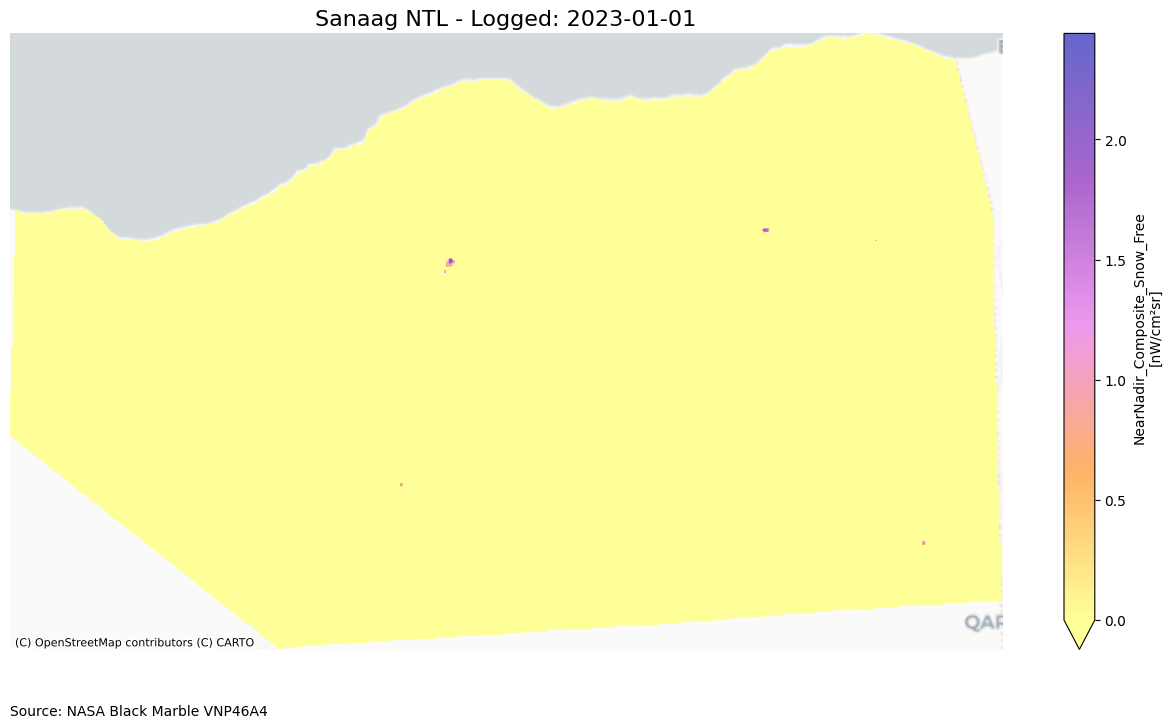

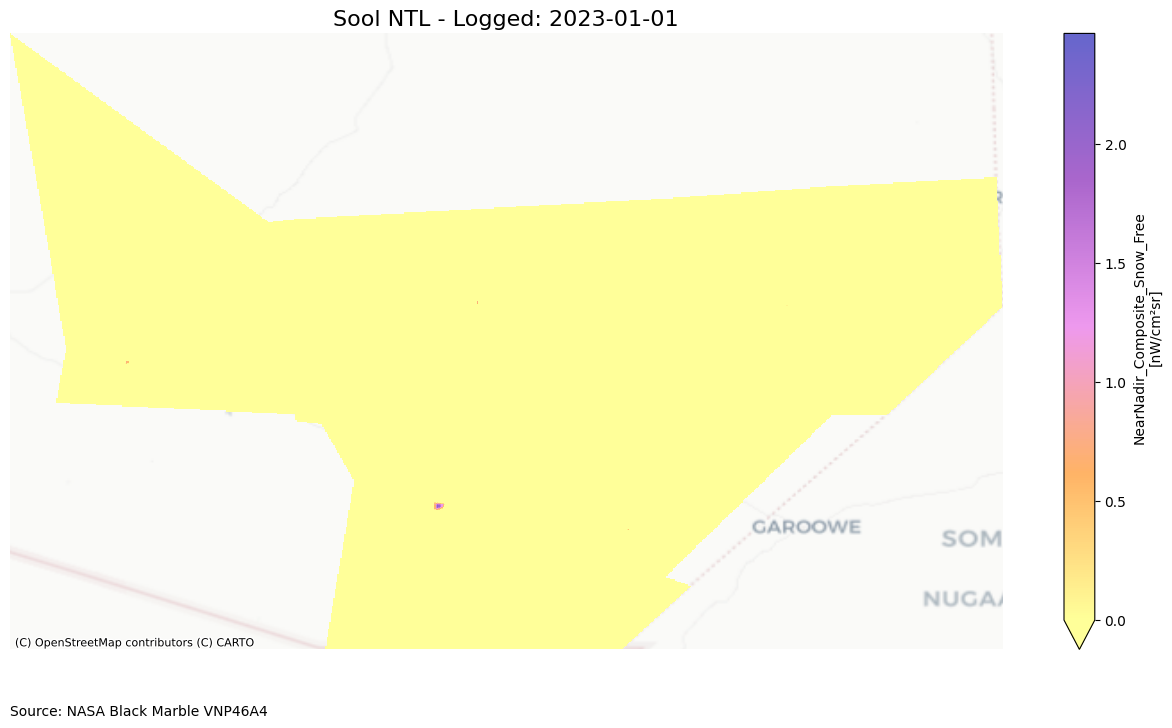

In [7]:
# 0 : "Maroodi Jeex",
# 1 : "Sahil",
# 2 : "Awdal",
# 3 : "Togdheer",
# 4 : "Sanaag",
# 5 : "Sool"

for year in [2012, 2023]:
    for i in range(0,6):
        region = list(log_region_list.keys())[i]
        data = log_region_list[region]
        plot_NASA_NTL(data, somaliland_shp[somaliland_shp["admin1Name"]==f"{region}"], date = f"{year}-01-01", 
                      variable = "NearNadir_Composite_Snow_Free",
                      title_prefix = f"{region} NTL - Logged", cmap=NTL_cmap,
                      robust = False, vmin=0, vmax = data["NearNadir_Composite_Snow_Free"].max())
        #plt.savefig(f'../output/Graphics/{region}_{year}.png', dpi=300, bbox_inches='tight')  

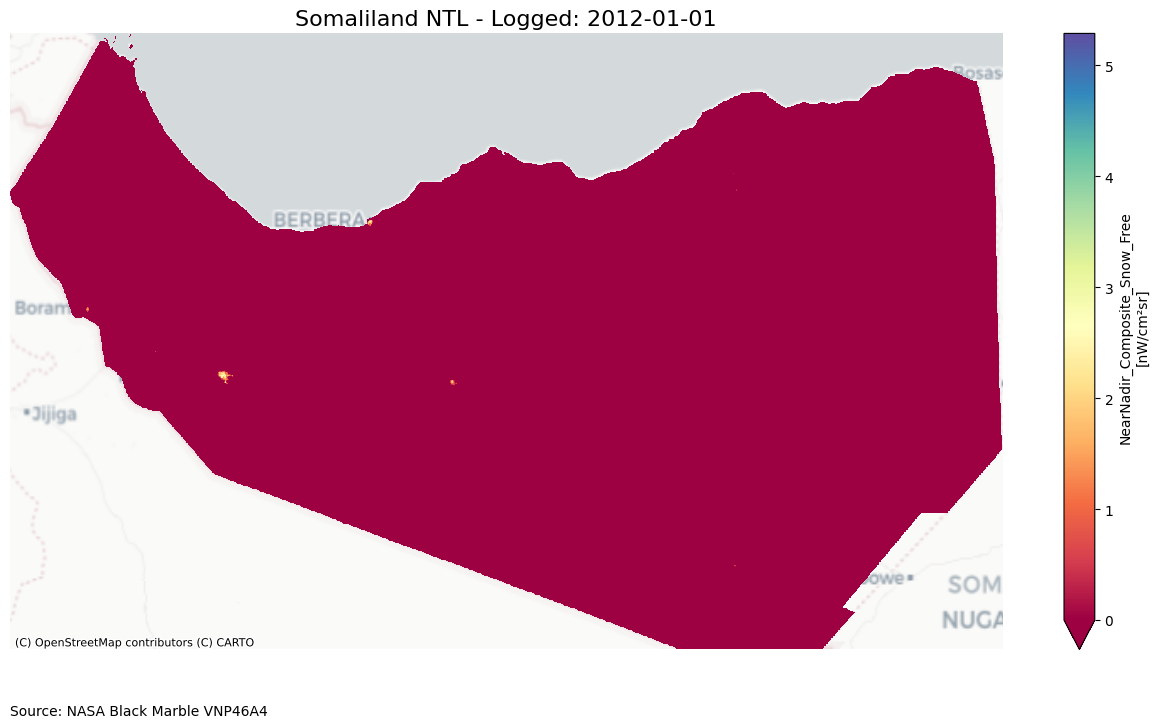

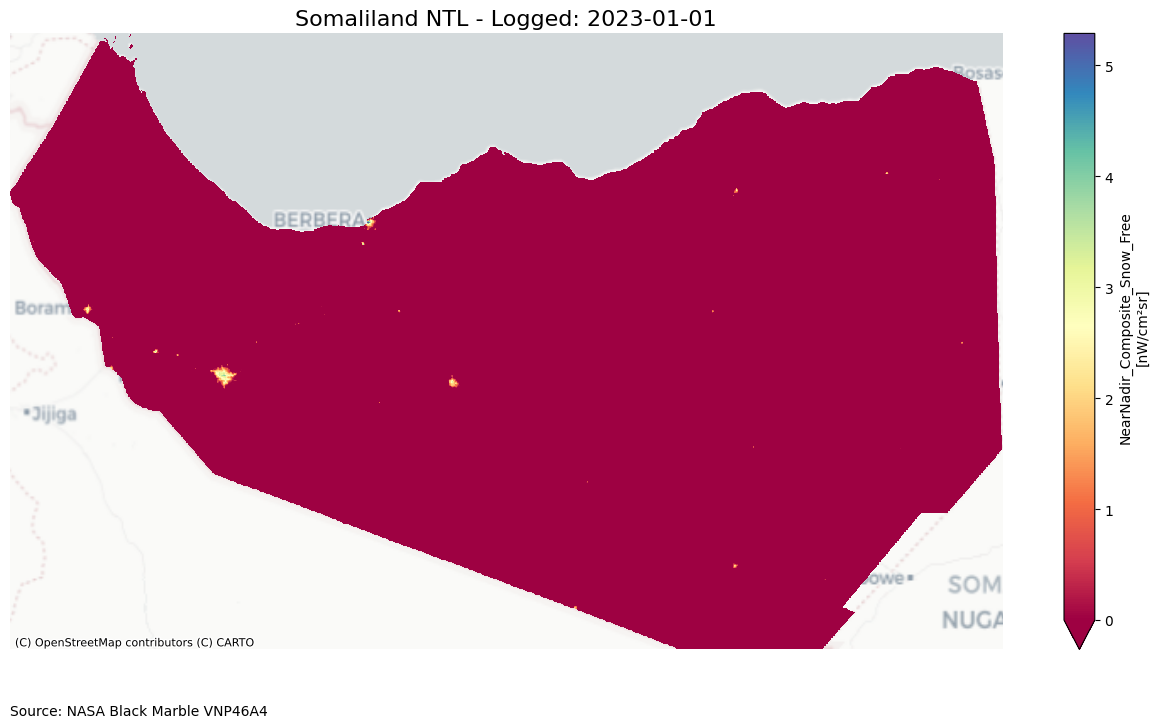

In [8]:
for year in [2012,2023]:
    plot_NASA_NTL(logged_NTL, somaliland_shp, date = f"{year}-01-01", 
                    variable = "NearNadir_Composite_Snow_Free",
                    title_prefix = "Somaliland NTL - Logged",
                    cmap="Spectral",
                    robust = False, vmin=0, vmax = logged_NTL["NearNadir_Composite_Snow_Free"].max())
    #plt.savefig(f'../output/Graphics/{region}_{year}.png', dpi=300, bbox_inches='tight')  

In [27]:
all_region_yearly_pixels = {}

for region_name, region_data in zip(region_names, region_datasets):
    yearly_pixels = []
    for year in range(2012, 2024):
        value = (region_data["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01") > 0).sum().item()
        yearly_pixels.append(value)
    all_region_yearly_pixels[region_name] = yearly_pixels


regions_pixels = pd.DataFrame(all_region_yearly_pixels)
regions_pixels["Year"] = list(range(2012, 2024))
regions_pixels = regions_pixels[["Year"] + region_names]

regions_pixels["Total"] = regions_pixels[region_names].sum(axis=1)

total = []
for year in range(2012, 2024):
    value = (SL_Berbera_VNP46A4_EY_2012_24["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01") > 0).sum().item()
    total.append(value)
#total

In [42]:
pixel_growth_rates = regions_pixels.set_index("Year").pct_change().multiply(100).round(1)
pixel_growth_rates

,Maroodi Jeex,Sahil,Awdal,Togdheer,Sanaag,Sool,Total
Year,,,,,,,
2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013,-3.5,2.9,17.5,-5.6,-15.4,200.0,2.1
2014,15.9,13.9,-4.3,19.0,36.4,18.2,15.0
2015,20.4,4.9,6.7,4.0,-13.3,2.6,13.3
2016,0.9,-1.2,-8.3,1.0,30.8,-2.5,0.4
2017,13.8,15.3,34.1,19.0,58.8,10.3,16.7
2018,12.9,25.5,40.7,28.8,18.5,9.3,18.4
2019,7.6,5.7,1.2,12.4,37.5,6.4,8.5
2020,15.7,16.2,29.8,10.5,6.8,18.0,15.7


In [43]:
print(pixel_growth_rates)

      Maroodi Jeex  Sahil  Awdal  Togdheer  Sanaag   Sool  Total
Year                                                            
2012           NaN    NaN    NaN       NaN     NaN    NaN    NaN
2013          -3.5    2.9   17.5      -5.6   -15.4  200.0    2.1
2014          15.9   13.9   -4.3      19.0    36.4   18.2   15.0
2015          20.4    4.9    6.7       4.0   -13.3    2.6   13.3
2016           0.9   -1.2   -8.3       1.0    30.8   -2.5    0.4
2017          13.8   15.3   34.1      19.0    58.8   10.3   16.7
2018          12.9   25.5   40.7      28.8    18.5    9.3   18.4
2019           7.6    5.7    1.2      12.4    37.5    6.4    8.5
2020          15.7   16.2   29.8      10.5     6.8   18.0   15.7
2021          27.0   50.3   44.0      20.0    95.7   50.8   33.5
2022          36.3   53.3   36.9      32.1    40.2   29.2   37.8
2023           4.7   18.4    1.4      -1.3    29.5  -15.7    5.9
